# Memristor

## Import and Formatting

The goal of this section is to import all the necessary files and libraries required for the subsequent data analysis.  
It also includes setting up the formatting parameters for the plots and visualizations.

### Import

In [1]:
# ----  Standard import
import matplotlib.pyplot as plt
import numpy as np

# ----- Spice import
from PySpice.Spice.Netlist import Circuit, SubCircuit
from PySpice.Unit import *

### Formatting

Adjusting Plotly chart settings for clarity and consistency.

In [2]:
# ----  Formatting charts
%matplotlib inline
from IPython.core.pylabtools import figsize
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.edgecolor']  = "#bcbcbc"
mpl.rcParams['patch.linewidth'] = 0.5
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['axes.facecolor']  = "#eeeeee"
mpl.rcParams['axes.labelsize']  = "large"
mpl.rcParams['axes.grid']       = True
mpl.rcParams['grid.linestyle']  = "--"
mpl.rcParams['patch.edgecolor'] = "#eeeeee"
mpl.rcParams['axes.titlesize']  = "x-large"

## Memristor

Memristors are electronic components that were **theoretically predicted in 1971 by Leon O. Chua**. However, it was not until **2008** that a research team at **HP** fabricated the first physical memristor.
Like resistors, the unit of a memristor is the **ohm (Ω)**.

The main difference between a **resistor** and a **memristor** lies in their behavior. A resistor has a **fixed value**; it is a scalar quantity. In contrast, a memristor is described by a **nonlinear function** that depends on the history of the device. This comparison is summarized in [](#memristor_resistance).

Unlike a resistor, whose value remains constant, the resistance of a memristor **evolves as a function of the applied voltage (or current) and the duration of excitation**. In particular, when a current flows in one direction, the memristance decreases, while a current flowing in the opposite direction causes the memristance to increase, the summary is in [](#memristor_change).

```{figure} ./images/memristor_change.svg
:name: memristor_change
:align: center
:width: 400px

Memristor change value resistance
```

```{table} Memristor vs. resistor
:name: memristor_resistance
:align: center

|                  | Resistor             | Memristor              |
|------------------|----------------------|------------------------|
| Unit             | Ohm (Ω)              | Ohm (Ω)                |
| Constitutive law | $U = R \cdot I$      | $U = M(q) \cdot I$     |
| Parameter type   | $R$ is constant      | $M(q)$ is variable     |
```

One of the **key advantages** of a memristor is that, when it is no longer powered by a current or voltage source, it **retains its resistance value**. This non-volatile property alone opens the door to many applications.

For example, memristors can be used to build **non-volatile RAM**, meaning that memory contents are preserved even when a microcontroller or computer is powered off. This could enable **ultra-low-power systems** with **instantaneous startup times**.

Another important advantage is related to **scaling and integration**. Memristors are extremely small and can be **stacked in three-dimensional structures**, allowing much higher storage densities. In contrast, traditional resistors are difficult—if not impossible—to stack efficiently. As a result, future electronic circuits could achieve significantly higher spatial density.

Finally, modern computer architectures—whether **Von Neumann** or **Harvard**—suffer from the well-known **memory bottleneck**. Even with multi-level memory hierarchies (L1, L2, L3, etc.), processors often spend a significant amount of time waiting for data.
In theory, memristors make it possible to **perform computations directly inside memory**, enabling *in-memory computing*. This paradigm could dramatically reduce data movement and has the potential to **revolutionize modern electronics and computing architectures**.

## Equation

### Internal State

The derivation of the equation is presented in the notebook *[*Basic Concepts*](./Concept_base)*. The purpose of this section is not to revisit the derivation, but simply to state the equations used in the model. As reported by [@joglekarElusiveMemristorProperties2009], the window function is defined as:

$$
f(x) = 1 - (2x - 1)^{2p}
$$

The corresponding integral for $p=1$ is therefore :

$$
g(x, p=1) = -\frac{4}{3}x^{3} + 2x^{2} + C
$$

where $C$ is the integration constant.

```{dropdown} Demonstration for p = 1
The initial equation is:
$$f(x) = 1 - (2x - 1)^{2p}$$

For $p = 1$, we obtain:
$$f(x, p=1) = 1 - (2x - 1)^{2}$$

Expanding the square term:
$$(2x - 1)^2 = 4x^2 - 4x + 1$$

Therefore:
$$f(x, p=1) = 1 - (4x^2 - 4x + 1)$$
$$f(x, p=1) = 1 - 4x^2 + 4x - 1$$
$$f(x, p=1) = -4x^2 + 4x$$

**Integration**

We now integrate each term separately.

For the quadratic term:

$$\int -4x^2 \ dx = -\frac{4}{3}x^3$$

For the linear term:

$$\int 4x \ dx = 2x^2$$

Combining both results gives:

$$g(x, p=1) = -\frac{4}{3}x^3 + 2x^2$$

Thus, we confirm that:

$$g(x, p=1) = \int f(x, p=1)\ dx$$

and therefore,

$$
\int \left[1 - (2x - 1)^2\right] \ dx = 
-\frac{4}{3}x^3 + 2x^2
$$

This result is consistent with the analytical expression previously introduced.
```

To integrate $f(x)$ for an arbitrary value of $p$, we obtain the following general expression:

$$g(x) = x - \frac{(2x - 1)^{2p + 1}}{2(2p + 1)} + C$$

where $C$ is the integration constant.

```{dropdown} Demonstration for arbitrary p

The initial equation is:

$$f(x) = 1 - (2x - 1)^{2p}$$

**Step 1 — Integrate term by term**

$$\int f(x)\,dx = \int \left[1 - (2x - 1)^{2p}\right] dx$$

We integrate each term separately.

First term:

$$\int 1 \ dx = x$$

Second term:

$$h(x) = \int (2x - 1)^{2p} dx$$

**Step 2 — Substitution**

Let:

$$u = 2x - 1$$

Then:

$$\frac{du}{dx} = 2 \quad \Rightarrow \quad dx = \frac{du}{2}$$

Substituting into the integral:

$$h(x) = \int u^{2p} \frac{du}{2}$$

$$h(x) = \frac{1}{2} \int u^{2p} du$$

**Step 3 — Power integration rule**

Using the standard power rule:

$$\int u^n du = \frac{u^{n+1}}{n+1}$$

we obtain:

$$h(x) = \frac{1}{2} \cdot \frac{u^{2p+1}}{2p+1}$$

$$h(x) = \frac{(2x - 1)^{2p+1}}{2(2p+1)}$$


**Final result**

Therefore:

$$
g(x) = \int f(x) \ dx= x - \frac{(2x - 1)^{2p + 1}}{2(2p + 1)} + C
$$

This completes the general proof for any integer (or real) value of $p$.
```


This expression will be used in the following sections to describe the evolution of the internal state variable.

In [3]:
# =========================
# Visualization function
# =========================
# ---- Constante
c1 = 0                # Integration constant

# ---- Domain of the state variable
x = np.linspace(-2, 2, 500)

# ---- Window function and its analytical integral
f    = lambda x, p: 1 - (2*x - 1)**(2*p)
g    = lambda x, p, c: x - (2*x - 1)**(2*p + 1) / (2*(2*p + 1))
g_p1 = lambda x, c: -4/3 * x**3 + 2 * x**2

```{note}
The ``g`` function and the ``g_p1`` function are the same; the only difference between the two is that the ``g_p1`` function only works when $p=1$, while the ``g`` function generalizes to all values of ``p``
```

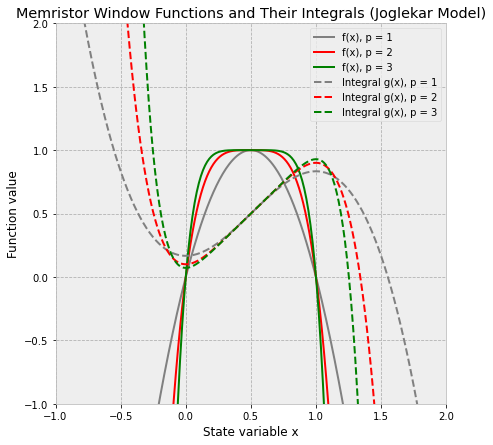

In [4]:
# =========================
# Plot the window functions 
# and their corresponding 
# integrals
# =========================
plt.figure(figsize=(7, 7))

plt.title("Memristor Window Functions and Their Integrals (Joglekar Model)")

# ---- Function f 
plt.plot(x, f(x, 1), label="f(x), p = 1", c="grey")
plt.plot(x, f(x, 2), label="f(x), p = 2", c="red")
plt.plot(x, f(x, 3), label="f(x), p = 3", c="green")

# ---- Integration of the f function g
plt.plot(x, g(x, 1, c1), '--', label="Integral g(x), p = 1", c="grey")
plt.plot(x, g(x, 2, c1), '--', label="Integral g(x), p = 2", c="red")
plt.plot(x, g(x, 3, c1), '--', label="Integral g(x), p = 3", c="green")

# ---- Parameter of the graph
plt.legend()
plt.ylim(-1, 2)
plt.xlim(-1, 2)
plt.xlabel("State variable x")
plt.ylabel("Function value")
plt.show()

## Internal State Dynamics

This curve represents the **internal state variable** of a memristor, which typically varies between 0 and 1.
The function $f(x)$ describes the **rate of change of the internal state**:

* If $x$ is close to $0$ or $1$ (near the boundaries), then $f(x,p) \rightarrow 0$, meaning the state changes **very slowly**.
* If $x$ is close to $0.5$ (the center), then $f(x,p)$ reaches its **maximum**, and the state evolves **more rapidly**.

The evolution of the internal state can therefore be written as:

$$
\frac{dx}{dt} = k \cdot I(t) \cdot f(x)
= k \cdot I(t) \cdot \bigl(1 - (2x - 1)^{2p}\bigr)
$$

where $k$ is a device-dependent constant and $I(t)$ is the current flowing through the memristor.

## Resistance Variation

As discussed previously, the memristor resistance changes as a function of the applied excitation and its duration. The resistance is expressed as:

$$R(x) = R_{ON}, x + R_{OFF}, (1 - x)$$

where:

* $R_{ON}$ is the resistance of the **doped region**,
* $R_{OFF}$ is the resistance of the **undoped region**,
* $x$ represents the **normalized position of the boundary** between the doped and undoped regions, i.e., the ratio of the doped-region length to the total device length.

```{figure} ./images/equation_resistance_memristor.svg
:name: equation_resistance_memristor
:align: center
:width: 400px

Memristor resistance model parameters
```

The [](#equation_resistance_memristor) summarizes the parameters involved in this model.
This equation provides the **instantaneous resistance value** as a function of the relative sizes of the doped and undoped regions. However, at this stage, it does not yet describe the **dynamic evolution** of the system, which requires combining the resistance equation with the state-evolution equation introduced above.

## I–V Characteristic Plot

The input excitation is assumed to be an **ideal sinusoidal voltage source**, given by:

$$V(t) = \sin(\omega t)$$

Injecting this expression into the internal state equation yields:

$$\frac{dx}{dt} = k \sin(\omega t)$$

which integrates to:

$$x(t) = -k \cos(\omega t) + C$$

where $C$ is an integration constant. In this study, the constant is assumed to be $C = 0$ for simplicity.

### Conductance Model

The chosen conductance model $G(x(t))$ is exponential. While the full physical justification for selecting an exponential form is beyond the scope of this work, this choice allows for a smooth and strongly nonlinear dependence of conductance on the internal state variable. The model is therefore defined as:

$$G(x(t)) = e^{x(t)}$$

Substituting the expression of $x(t)$ gives:

$$G(t) = e^{-k \cos(\omega t) + C}$$

### Current Expression

The memristor current is obtained from the relation:

$$I(t) = G(t), V(t)$$

By injecting the expressions of $G(t)$ and $V(t)$, we obtain:

$$I(t) = e^{-k \cos(\omega t) + C} \sin(\omega t)$$

### Parametric I–V Representation

The parametric equations describing the memristor behavior are therefore:

$$
\begin{cases}
V(t) =  \sin(\omega t) \\
I(t) = e^{-k \cos(\omega t) + C} \cdot \sin(\omega t)
\end{cases}
$$

These equations can be used to plot the characteristic **pinched hysteresis loop** of the memristor in the current–voltage (I–V) plane.

In [5]:
# =========================
# Init function
# =========================
# ---- constant
c1 = 0  # Integration constant

# ---- Time vector
t = np.linspace(0, 100, 1000)

# ---- function
# Single-frequency I–V curve
v = np.sin(t)                # Applied voltage
x = -np.cos(t)               # Internal state evolution
i = (np.exp(x + c1)) * v     # Memristor current

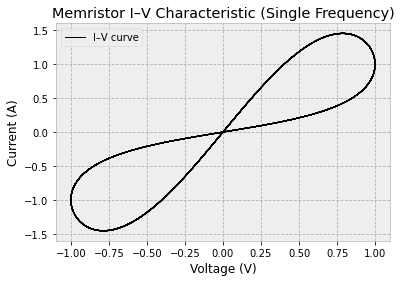

In [6]:
# =========================
# Plot I–V Characteristic
# =========================
plt.figure()

plt.title('Memristor I–V Characteristic (Single Frequency)')

# ---- I-V curve
plt.plot(v, i, label='I–V curve', lw=1, c="black")

# ---- Parameter of the graph
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.legend()
plt.show()

In [7]:
# =========================
# Influence of excitation 
# frequency on the I–V curve
# =========================
# ---- constant
w_list = [0.5, 1, 5]  # pulsation of the system
c1 = 0                # Integration constant

# ---- Time vector
t = np.linspace(0, 100, 1000)

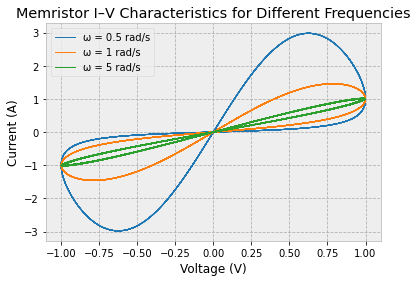

In [8]:
# =========================
# Plot I–V Characteristic
# =========================
plt.figure()

plt.title('Memristor I–V Characteristics for Different Frequencies')

# ---- I-V curve
for w in w_list:
    v = np.sin(w * t)              # Input voltage
    x = -np.cos(w * t) / w         # Internal state evolution
    i = (np.exp(x + c1)) * v       # Output current
    plt.plot(v, i, lw=1, label=f'ω = {w} rad/s')

# ---- Parameter of the graph
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.legend()
plt.show()

As the input frequency changes, the **voltage–current (I–V) characteristic** also varies.
When the excitation frequency increases, the **hysteresis loop shrinks**, eventually approaching a nearly linear resistive behavior. Conversely, at lower excitation frequencies, the **hysteresis loop becomes wider**, indicating stronger memory effects in the device.

In the next section, the objective is to design and simulate a **memristor model**.

## Memristor Implementation in SPICE

The goal is to implement a memristor using SPICE. The circuit configuration used in this study is illustrated below.

```{figure} ./images/memristor.svg
:name: memristor_pyspice
:align: center
:width: 400px

Memristor implementation in PySpice
```

In [9]:
class Memristor(SubCircuit):
    '''
    Link of the program : https://github.com/jurjsorinliviu/In-Situ-Memristive-Learning-Method-for-Pattern-Classification/blob/main/memristor.py
    '''
    def __init__(self, name, K=0.00005, Kp=0.13*10**-3, 
                 C=0.1@u_pF, Vto=0, 
                 SwitchRoff=10**20, SwitchRon=10**-3):
        __nodes__ = ('S', 'D', 'phi')
        
        self.cmem = 'Cmem'
        self.o    = 'o'
        
        SubCircuit.__init__(self, name, *__nodes__)
        # self.parameters = {'K': K, 'Kp': Kp, 'C': C, 'Vto': Vto}
        self.VCCS('g', self.gnd, self.o, 'D', 'S', K)
        self.R(1, 'o', self.gnd, 1e12)
        self.VoltageControlledSwitch('sw', self.o, self.cmem, 'phi', 
                                     self.gnd, model='my_switch')
        self.model('my_switch', "SW", Ron=SwitchRon, Roff=SwitchRoff, 
                   Vt=0.5)
        self.C(1, self.gnd, self.cmem, C)
        
        # M1 drain gate source body
        self.model('my_nmos', 'NMOS', level=3, Vto=Vto, Kp=Kp)
        self.MOSFET('m', 'D', self.cmem, 'S', self.gnd, model='my_nmos');

### Description code

#### Voltage-Controlled Current Source (VCCS)

```python
self.VCCS('g', self.gnd, 'o', 'D', 'S', K)
```

The first element is a **voltage-controlled current source (VCCS)**. This component generates a current proportional to a control voltage, leading to the following relation, which corresponds to the internal-state dynamics of the memristor:

$$I(t) = k, V(t)$$

* $k$ is the gain of the controlled current source and represents the **rate of evolution of the internal state**.
* $V(t)$ is the voltage difference between nodes $S$ and $D$.
* $I(t)$ is used to **charge the capacitor**, thereby updating the internal memory state.

#### Large Resistor $R$

```python
self.R('1', 'o', self.gnd, 1e9)
```

This resistor has a very large value (on the order of gigaohms), making it effectively an open circuit. Its role is purely related to **numerical stability**: it prevents floating nodes and ensures convergence during SPICE simulations. It has no significant influence on the physical behavior of the memristor.

#### Voltage-Controlled Switch

```python
self.VoltageControlledSwitch('sw', 'o', 'Cmem', 'phi', self.gnd, model='my_switch')
```

This element is a **voltage-controlled switch** placed between nodes `o` and `Cmem`. The switch is controlled by the voltage at node `phi`, allowing or blocking the evolution of the memory state.

The switch model is defined as:

```python
self.model('my_switch', "SW", Ron=SwitchRon, Roff=SwitchRoff, Vt=0.5)
```

The operating states of the switch are summarized in Table [](#Swith_state).

```{table} Switch state
:name: Swith_state
:align: center

| State | Condition        |
| ----- | ---------------- |
| ON    | $V(\phi) > 0.5$ V |
| OFF   | $V(\phi) < 0.5$ V |
```

This mechanism allows the **memory update to be enabled or disabled**.

#### Capacitor: Memory Element

```python
self.C(1, self.gnd, 'Cmem', C)
```

The capacitor stores the voltage $V(\text{Cmem})$, which represents the **internal state of the memristor**. The stored charge corresponds to the accumulated effect of the past current:

$$V_{\text{Cmem}} \propto \int I(t) \ dt$$

Thus, the capacitor implements the **memory** of the device.

#### MOSFET (Resistance Control)

```python
self.model('my_nmos', 'NMOS', level=3, Vto=Vto, Kp=Kp)
self.MOSFET(1, 'D', 'Cmem', 'S', self.gnd, model='my_nmos')
```

The MOSFET gate is driven by the voltage at node `Cmem`. As a result, the **drain–source resistance** becomes dependent on the stored internal state. This allows the memristor resistance to vary according to its memory, reproducing the fundamental memristive behavior.

#### Model Parameters

```python
K = 0.00005
Kp = 0.13e-3
C = 0.1 @ u_pF
Vto = 0
SwitchRoff = 1e20
SwitchRon = 1e-3
```

The input parameters of the memristor model are summarized in Table [](#input_parameter_of_the_memristor).

```{table} Input parameters of the memristor
:name: input_parameter_of_the_memristor
:align: center

| Parameter     | Description                                                  |
| ------------- | ------------------------------------------------------------ |
| `K`           | Gain of the controlled current source (state evolution rate) |
| `Kp`          | NMOS transconductance parameter                              |
| `C`           | Capacitance that **stores the memory**                       |
| `Vto`         | NMOS threshold voltage                                       |
| `SwitchRon`   | ON resistance of the switch                                  |
| `SwitchRoff`  | OFF resistance of the switch                                 |
```

In the next section, the objective is to **validate the circuit** by generating and analyzing the memristor **current–voltage (I–V) characteristics**.

### Spice Simulation

In [10]:
# =========================
# Initial conditions
# =========================
vs = 0        # Tension point S
vd = 1        # Tension point D
phi = 1.2     # Autorisation de la modification de la résistance du memristor

In [11]:
# =========================
# Plot I–V Characteristic
# =========================

# ---- Create the circuit
circuit = Circuit('Memristor')

# ---- Include memristor model
memristor = Memristor('Mem1', K=0.0002, Kp=0.13*10**-3, C=0.1@u_pF, Vto=0)
circuit.subcircuit(memristor)

# ---- Power Supply
circuit.V('S', 'S', circuit.gnd, vs@u_V)
circuit.SinusoidalVoltageSource('D', 'D', circuit.gnd, amplitude=vd@u_V, frequency=1@u_kHz, offset=0@u_V)
circuit.V('phi', 'phi', circuit.gnd, phi@u_V)

# ---- Creation memristor
circuit.X('Mem1', 'mem1', 'S', 'D', 'phi');

In [12]:
simulator = circuit.simulator(temperature=25, nominal_temperature=25)
analysis = simulator.transient(step_time=0.0001@u_ms, end_time=10@u_ms, use_initial_condition=True)

# ============================================================
# Simulation Setup
# Transient analysis of the CMOS logic gate
# ============================================================

# Create the simulator instance
# Temperature parameters are set to nominal operating conditions
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# ============================================================
# Transient Analysis
# ============================================================

# Perform a transient simulation to observe the dynamic behavior
# of the inputs (A, B) and the output (Vout)
analysis = simulator.transient(
    step_time = .0001 @ u_ms,
    end_time  = 10    @ u_ms,
)

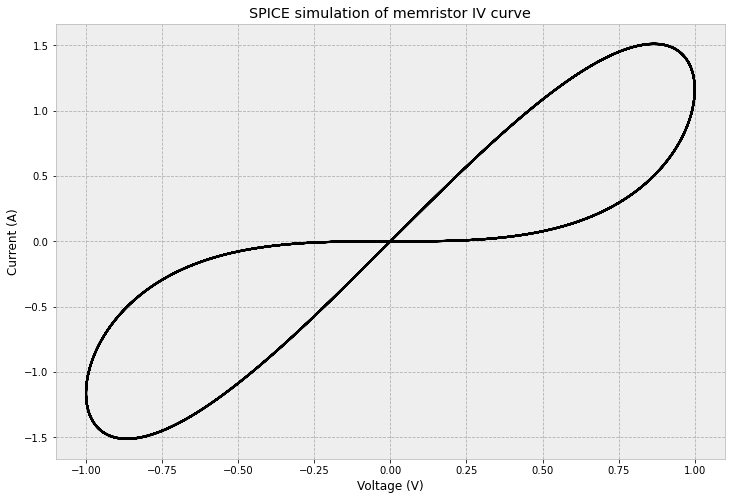

In [13]:
# =========================
# Vds
# =========================
vds = np.array(analysis['D']) - np.array(analysis['S'])


# =========================
# Plot I–V Characteristic
# =========================
plt.figure(figsize=(12, 8))

# ---- I-V curve
plt.plot(vds, np.array(analysis.branches['vs']), c='black')

# ---- Parameter of the graph
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.title("SPICE simulation of memristor IV curve")
plt.show();

It is possible to see that the I-V signal perfectly matches the input that was theorized in the previous section. In the next section, the objective is to see how this evolves over time.

In the next section, the goal is to see what the phi signal is used for.

## Importance of phi

In [14]:
# =========================
# Initial conditions
# =========================
vs = 0        # Voltage at node S
vd = 1        # Voltage amplitude at node D
phi = 1.2     # Enables modification of the memristor resistance

In [15]:
# =========================
# Importance of phi
# =========================

# ---- Create the circuit
circuit = Circuit('Memristor')

# ---- Include memristor model
memristor = Memristor('Mem1', K=0.0002, Kp=0.13e-3, C=0.1 @ u_pF, Vto=0)
circuit.subcircuit(memristor)


# ---- Input Signal Definitions
circuit.V('S', 'S', circuit.gnd, vs @ u_V)
circuit.PulseVoltageSource(
    'phi',
    'phi',
    circuit.gnd,
    0 @ u_V, phi @ u_V,
    pulse_width=3 @ u_ms,
    period=6 @ u_ms,
)

circuit.SinusoidalVoltageSource(
    'D', 'D', circuit.gnd,
    amplitude=vd @ u_V,
    frequency=1 @ u_kHz,
    offset=0 @ u_V
)

# ---- Creation memristor
circuit.X('Mem1', 'mem1', 'S', 'D', 'phi');

In [16]:
# =========================
# Simulation Setup
# =========================

# Create the simulator instance
# Temperature parameters are set to nominal operating conditions
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# =========================
# Transient Analysis
# =========================

# Perform a transient simulation to observe the dynamic behavior
analysis = simulator.transient(
    step_time = 0.001 @ u_ms,
    end_time = 10 @ u_ms,
)

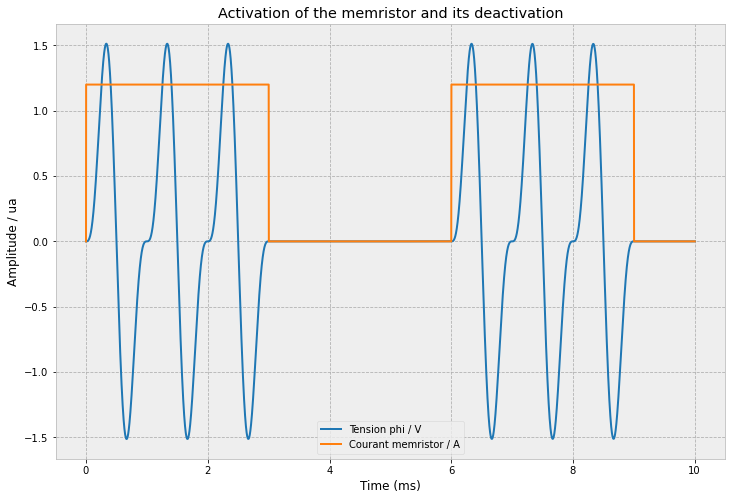

In [17]:
# =========================
# Get variable
# =========================
ids    = np.array(analysis.branches['vs'])  # Currant in the memresistor
time  = np.array(analysis.time)           # Time
phi_t = np.array(analysis['phi'])         # Value of phi

# =========================
# Plot phi
# =========================
plt.figure(figsize=(12, 8))

# --- plot wave
plt.plot(time*1e3, ids,   label="Tension phi / V")
plt.plot(time*1e3, phi_t, label="Courant memristor / A")

# ---- Parameter of the graph
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude / ua')
plt.title('Activation of the memristor and its deactivation')
plt.legend()
plt.show()

When $\phi$ (*orange curve*) is above $0.5 \ V $, current is able to flow through the memristor (*blue curve*). This occurs in the time intervals between $0$ and $3 \ ms$, and between $6$ and $10 \ ms$.

However, when $\phi$ (*orange curve*) falls below $0.5 \ V$, current can no longer flow through the memristor.

There is still much more to explore about this circuit, particularly regarding the role and influence of $\phi$.

## Resistance evolution of the Memristor

The resistance value of a memristor changes according to three factors: first, the applied voltage; second, the duration of the application; and third, the direction of the voltage. The objective of the next section is to verify these three statements.

In [63]:
# =========================
# Initial conditions
# =========================
vs = 0        # Voltage at node S
vd = 2        # Voltage amplitude at node D
vd_half = 0.5 # Half voltage amplitude at node D
phi = 1.2     # Enables modification of the memristor resistance
mid = "1ms"    # Half of the signal
f   = 1e3

In [64]:
# =========================
# Importance of phi
# =========================

# ---- Create the circuit
circuit = Circuit('Memristor resistance evolution')

# ---- Include memristor model
memristor = Memristor('Mem1', K=0.0002, Kp=0.13e-3, C=0.1 @ u_pF, Vto=0)
circuit.subcircuit(memristor)


# ---- Input Signal Definitions
circuit.V('S', 'S', circuit.gnd, vs @ u_V)
circuit.V('phi', 'phi', circuit.gnd, phi @ u_V)

circuit.BehavioralSource(
    'D', 'D', circuit.gnd,
    voltage_expression=f'(time < {mid} ? {vd} : {vd_half}) * sin(2*pi*{f}*time)'
)


# ---- Creation memristor
circuit.X('Mem1', 'mem1', 'S', 'D', 'phi');

```{note}
It is possible to see that there is a function called ``BehavioralSource``. This current source allows control of different parameters as a function of time. From $0$ to $1 \ ms$, the amplitude is $1 \ V$, and after $1 \ ms$, the amplitude is $0.5 \ V$. Therefore, the equation is:
$$
V(t)=
\begin{cases}
1 \cdot \sin(2\pi f t) & t < 1 \ ms \\
0.5 \cdot \sin(2\pi f t) & t \ge 1 \ ms
\end{cases}
$$
```

In [65]:
# =========================
# Simulation Setup
# =========================

# Create the simulator instance
# Temperature parameters are set to nominal operating conditions
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# =========================
# Transient Analysis
# =========================

# Perform a transient simulation to observe the dynamic behavior
analysis = simulator.transient(
    step_time = 0.001 @ u_ms,
    end_time = 2 @ u_ms,
)

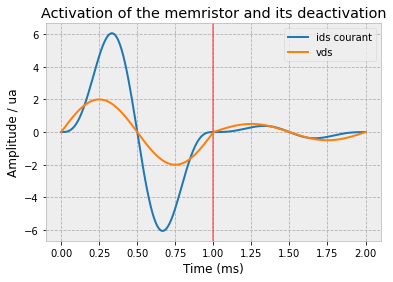

In [79]:
# =========================
# Get variable
# =========================
time  = np.array(analysis.time)                            # Time
ids    = np.array(analysis.branches['vs'])                 # Currant in the memresistor
vds    = np.array(analysis['d']) - np.array(analysis['s']) # Tension in the memresistor

# =========================
# Plot resistance current
# =========================
plt.figure()

# --- plot wave
plt.axvline(1, c="red", alpha=.4)
plt.plot(time*1e3, ids,   label="ids courant")
plt.plot(time*1e3, vds,   label="vds")


# ---- Parameter of the graph
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude / ua')
plt.title('Activation of the memristor and its deactivation')
plt.legend()
plt.show()

The voltage curve is shown in orange. Before 1 ms, the signal amplitude is 2 V, but after that time, the signal amplitude is only 0.5 V. It is possible to see that on these graph.

It is possible to see that the voltage and current change over time, but not in the same way, which means that the resistance also changes over time. The objective of the next section is to visualize this.

In [80]:
# =========================
# Resistance Calculate
# =========================
# ---- constant
epsilon = 1e-12   # just for limite 0 divise

# ---- resistance
resistance = vds / (ids+epsilon)

# ---- Divised wave
part_1_evolu_resist = resistance[0:len(resistance)//2]    # 0 ms to 1 ms
part_2_evolu_resist = resistance[len(resistance)//2:-1]   # 1 ms to 2 ms

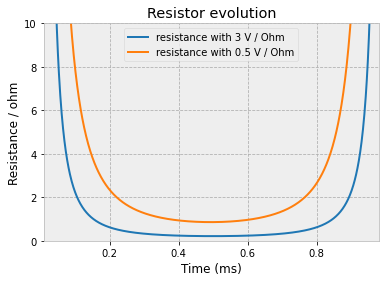

In [84]:
# =========================
# Plot resistance
# =========================
plt.figure()

# --- plot wave
plt.plot(time[0:len(part_1_evolu_resist)]*1e3, part_1_evolu_resist,   label="resistance with 3 V / Ohm")
plt.plot(time[0:len(part_2_evolu_resist)]*1e3, part_2_evolu_resist,   label="resistance with 0.5 V / Ohm")

# ---- Parameter of the graph
plt.xlabel('Time (ms)')
plt.ylabel('Resistance / ohm')
plt.xlim(.01, 0.98)
plt.ylim(0, 10)
plt.title('Resistor evolution')
plt.legend()
plt.show()

From the graph, we can observe that the higher the applied voltage, the greater the decrease in resistance. The curve corresponding to 3 V shows a faster and more pronounced drop in resistance compared to the 0.5 V case.

Furthermore, the longer the voltage is applied, the larger the change in resistance, whether it is decreasing or increasing.

It is also important to note the presence of a lower plateau: the resistance does not decrease indefinitely but appears to reach a minimum limit value.

There is still much to say about memristors, but for now the study will stop here.

## Reference

```{bibliography}
```

## Writing Matrix

| Author | Reviewer | Approver | Section | Date 1 | Date 2 | Date 3 | General Remarks |
|--------|----------|----------|---------|--------|--------|--------|------------------|
| Sacha  | /        | /        | Entire document | 2026-02-07 | / | / | Initial draft of the full document |